# Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Load the training data.

In [5]:
train_df = pd.read_csv("/content/train.csv")
print(train_df)

        id                                             prompt  \
0        1  Pick the best possible answer: What is Martin ...   
1        2        What is accelerator-based light-ion fusion?   
2        3  Determine the correct option: What is the term...   
3        4  Select the most accurate option: What is Marti...   
4        5  Identify the correct statement: What is the co...   
...    ...                                                ...   
1995  1996  What is the piezoelectric strain coefficient f...   
1996  1997  Identify the correct statement: What is the sy...   
1997  1998  Determine the correct option: What does Earnsh...   
1998  1999  Identify the correct statement: What is the re...   
1999  2000  Pick the best possible answer: Which of the fo...   

                                                      A  \
0     Martin Heidegger believes that humans exist wi...   
1     Accelerator-based light-ion fusion is a techni...   
2                                         

# Data Analysis

In [6]:
# Info on the train data to see the type of columns.
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [9]:
# See some data stored in the training data to see how it looks like.
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Looking into the **answer** column.



In [17]:
# See what all comes as the answer options.
print("Possible answer options in the training data:", train_df["answer"].unique())

# Distribution of options across the training data
print("Distribution of answer column")
print(train_df["answer"].value_counts())

Possible answer options in the training data: ['B' 'A' 'C' 'E' 'D']
Distribution of answer column
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


<Axes: xlabel='answer'>

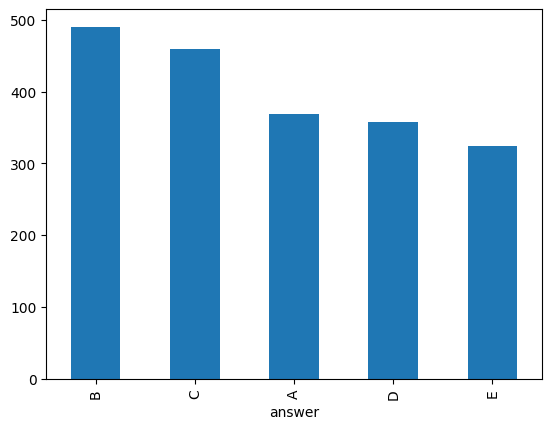

In [19]:
# Visualize the distribution.
train_df["answer"].value_counts().plot(kind="bar")

## Looking into the **prompt** column.

In [42]:
# Number of characters in the prompt column
total_chars = train_df["prompt"].apply(len).sum()
num_of_prompts = train_df.shape[0]
print("Sum of characters in the prompt column:", total_chars)
print("Total num of prompts:", num_of_prompts)

print("Average Character count:", total_chars/num_of_prompts)
print("Maximum Character count in a single prompt:", train_df["prompt"].apply(len).max())
print("Minimum Chracter count in a single prompt:", train_df["prompt"].apply(len).min())

print("===================================")
print("Minimum Character prompt:", train_df.iloc[train_df["prompt"].apply(len).idxmin()]["prompt"])
print("Maximum Character prompt:\n", train_df.iloc[train_df["prompt"].apply(len).idxmax()]["prompt"])

Sum of characters in the prompt column: 235339
Total num of prompts: 2000
Average Character count: 117.6695
Maximum Character count in a single prompt: 337
Minimum Chracter count in a single prompt: 19
Minimum Character prompt: What is emissivity?
Maximum Character prompt:
 Identify the correct statement: What is one of the examples of the models proposed by cosmologists and theoretical physicists without the cosmological or Copernican principles that can be used to address specific issues in the Lambda-CDM model and distinguish between current models and other possible models? based on the given context.


In [55]:
def to_words(data):
  words = data.split(" ")
  return len(words)
# Number of words in the prompt column.
total_words = train_df["prompt"].apply(to_words).sum()

print("Total Number of words in the prompt column:", total_words)
print("Total Number of prompts:", num_of_prompts)

print("Average word count in the prompt column:", total_words/num_of_prompts)
print("Maximum word count in a single prompt:", train_df["prompt"].apply(to_words).max())
print("Minimum word count in a single prompt:", train_df["prompt"].apply(to_words).min())

Total Number of words in the prompt column: 36293
Total Number of prompts: 2000
Average word count in the prompt column: 18.1465
Maximum word count in a single prompt: 51
Minimum word count in a single prompt: 3


## Look into an entire single row of data.

In [65]:
index = random.randint(0,2000)
print("Prompt:", train_df.iloc[index]["prompt"])
print("Option A:", train_df.iloc[index]["A"])
print("Option B:", train_df.iloc[index]["B"])
print("Option C:", train_df.iloc[index]["C"])
print("Option D:", train_df.iloc[index]["D"])
print("Option E:", train_df.iloc[index]["E"])
print("Answer:", train_df.iloc[index]["answer"],":", train_df.iloc[index][train_df.iloc[index]["answer"]])

Prompt: Select the most accurate option: What is the meaning of the term "horror vacui"? based on the given context.
Option A: The quantified extension of volume in empty space.
Option B: The commonly held view that nature abhorred a vacuum.
Option C: The medieval thought experiment into the idea of a vacuum.
Option D: The success of Descartes' namesake coordinate framework.
Option E: The spatial-corporeal component of Descartes' metaphysics.
Answer: B : The commonly held view that nature abhorred a vacuum.
